# OSSense — Large-Scale Open-Source Ecosystem Analytics

A Big Data Analytics project for studying large-scale GitHub activity using Apache Spark and GH Archive data.

**Analysis Period:** February 8–9, 2023

 1. Environment Setup

In [2]:
from pathlib import Path

OSSENSE_ROOT = Path("/content/drive/MyDrive/OSSense_Data")

for folder in [
    "raw",
    "processed",
    "results",
    "spark_tmp"
]:
    (OSSENSE_ROOT / folder).mkdir(parents=True, exist_ok=True)

print("OSSense cloud storage:")
print(OSSENSE_ROOT)

for folder in OSSENSE_ROOT.iterdir():
    print("✓", folder.name)

OSSense cloud storage:
/content/drive/MyDrive/OSSense_Data
✓ raw
✓ spark_tmp
✓ results
✓ processed


In [3]:
import sys
import subprocess

print("Python:", sys.version)

java = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True
)

print("Java:")
print(java.stderr)

try:
    import pyspark
    print("PySpark:", pyspark.__version__)
except ImportError:
    print("PySpark: NOT INSTALLED")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Java:
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)

PySpark: 4.0.4


In [4]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("OSSense")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Spark UI:", spark.sparkContext.uiWebUrl)
print("Spark master:", spark.sparkContext.master)

Spark version: 4.0.4
Spark UI: http://943f32e4f658:4040
Spark master: local[*]


In [5]:
test_df = spark.createDataFrame(
    [
        (1, "PushEvent"),
        (2, "IssuesEvent"),
        (3, "PullRequestEvent")
    ],
    ["id", "event_type"]
)

test_df.show()

+---+----------------+
| id|      event_type|
+---+----------------+
|  1|       PushEvent|
|  2|     IssuesEvent|
|  3|PullRequestEvent|
+---+----------------+



## 2. Dataset and Data Acquisition

In [6]:
import requests

url = "https://www.gharchive.org/"
response = requests.get(url, timeout=20)

print("GH Archive status:", response.status_code)
print("Source reachable:", response.ok)

GH Archive status: 200
Source reachable: True


In [7]:
import requests

dates = [
    "2023-02-08",
    "2023-02-09"
]

total_bytes = 0
available_files = 0

for date in dates:
    print(f"\nChecking {date}...")

    for hour in range(24):
        filename = f"{date}-{hour}.json.gz"
        url = f"https://data.gharchive.org/{filename}"

        r = requests.head(url, timeout=20)

        if r.status_code == 200:
            size = int(r.headers.get("Content-Length", 0))
            total_bytes += size
            available_files += 1

            print(
                f"{filename}: "
                f"{size / (1024**2):.1f} MB"
            )
        else:
            print(f"{filename}: HTTP {r.status_code}")

print("\n==============================")
print("Files available:", available_files)
print("Total compressed size:",
      round(total_bytes / (1024**3), 2), "GB")
print("==============================")


Checking 2023-02-08...
2023-02-08-0.json.gz: 100.3 MB
2023-02-08-1.json.gz: 80.8 MB
2023-02-08-2.json.gz: 74.8 MB
2023-02-08-3.json.gz: 76.0 MB
2023-02-08-4.json.gz: 80.3 MB
2023-02-08-5.json.gz: 72.5 MB
2023-02-08-6.json.gz: 77.4 MB
2023-02-08-7.json.gz: 83.8 MB
2023-02-08-8.json.gz: 97.3 MB
2023-02-08-9.json.gz: 106.9 MB
2023-02-08-10.json.gz: 107.5 MB
2023-02-08-11.json.gz: 100.7 MB
2023-02-08-12.json.gz: 103.0 MB
2023-02-08-13.json.gz: 109.8 MB
2023-02-08-14.json.gz: 111.6 MB
2023-02-08-15.json.gz: 117.2 MB
2023-02-08-16.json.gz: 112.0 MB
2023-02-08-17.json.gz: 108.4 MB
2023-02-08-18.json.gz: 107.0 MB
2023-02-08-19.json.gz: 98.0 MB
2023-02-08-20.json.gz: 97.1 MB
2023-02-08-21.json.gz: 96.4 MB
2023-02-08-22.json.gz: 96.6 MB
2023-02-08-23.json.gz: 82.6 MB

Checking 2023-02-09...
2023-02-09-0.json.gz: 91.0 MB
2023-02-09-1.json.gz: 76.9 MB
2023-02-09-2.json.gz: 71.9 MB
2023-02-09-3.json.gz: 65.2 MB
2023-02-09-4.json.gz: 65.2 MB
2023-02-09-5.json.gz: 64.0 MB
2023-02-09-6.json.gz: 72.1 

In [8]:
from pathlib import Path
import requests
import time

RAW_DIR = Path("/content/drive/MyDrive/OSSense_Data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

dates = [
    "2023-02-08",
    "2023-02-09"
]

total_expected = 0
total_downloaded = 0

for date in dates:
    for hour in range(24):

        filename = f"{date}-{hour}.json.gz"
        url = f"https://data.gharchive.org/{filename}"
        output_path = RAW_DIR / filename

        # Get expected size
        head = requests.head(url, timeout=30)
        head.raise_for_status()

        expected_size = int(head.headers.get("Content-Length", 0))
        total_expected += expected_size

        # Skip a file if it is already completely downloaded
        if output_path.exists() and output_path.stat().st_size == expected_size:
            print(f"✓ Already complete: {filename}")
            total_downloaded += expected_size
            continue

        print(f"\nDownloading: {filename}")
        print(f"Expected: {expected_size / (1024**2):.1f} MB")

        with requests.get(url, stream=True, timeout=60) as response:
            response.raise_for_status()

            with open(output_path, "wb") as f:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)

        actual_size = output_path.stat().st_size

        if actual_size != expected_size:
            raise RuntimeError(
                f"Size mismatch for {filename}: "
                f"expected {expected_size}, got {actual_size}"
            )

        total_downloaded += actual_size

        print(
            f"✓ Complete: {actual_size / (1024**2):.1f} MB"
        )

print("\n================================")
print("DOWNLOAD COMPLETE")
print("================================")
print(f"Files: 48")
print(f"Downloaded: {total_downloaded / (1024**3):.2f} GB")
print(f"Location: {RAW_DIR}")

✓ Already complete: 2023-02-08-0.json.gz
✓ Already complete: 2023-02-08-1.json.gz
✓ Already complete: 2023-02-08-2.json.gz
✓ Already complete: 2023-02-08-3.json.gz
✓ Already complete: 2023-02-08-4.json.gz
✓ Already complete: 2023-02-08-5.json.gz
✓ Already complete: 2023-02-08-6.json.gz
✓ Already complete: 2023-02-08-7.json.gz
✓ Already complete: 2023-02-08-8.json.gz
✓ Already complete: 2023-02-08-9.json.gz
✓ Already complete: 2023-02-08-10.json.gz
✓ Already complete: 2023-02-08-11.json.gz
✓ Already complete: 2023-02-08-12.json.gz
✓ Already complete: 2023-02-08-13.json.gz
✓ Already complete: 2023-02-08-14.json.gz
✓ Already complete: 2023-02-08-15.json.gz
✓ Already complete: 2023-02-08-16.json.gz
✓ Already complete: 2023-02-08-17.json.gz
✓ Already complete: 2023-02-08-18.json.gz
✓ Already complete: 2023-02-08-19.json.gz
✓ Already complete: 2023-02-08-20.json.gz
✓ Already complete: 2023-02-08-21.json.gz
✓ Already complete: 2023-02-08-22.json.gz
✓ Already complete: 2023-02-08-23.json.gz
✓ 

In [9]:
from pathlib import Path
import gzip
import json

RAW_DIR = Path("/content/drive/MyDrive/OSSense_Data/raw")

files = sorted(RAW_DIR.glob("*.json.gz"))

print("Number of files:", len(files))

total_bytes = sum(f.stat().st_size for f in files)

print(
    "Total size:",
    round(total_bytes / (1024**3), 2),
    "GB"
)

print("\nFirst 5 files:")
for f in files[:5]:
    print(" ", f.name)

Number of files: 48
Total size: 4.36 GB

First 5 files:
  2023-02-08-0.json.gz
  2023-02-08-1.json.gz
  2023-02-08-10.json.gz
  2023-02-08-11.json.gz
  2023-02-08-12.json.gz


In [10]:
sample_file = files[0]

with gzip.open(sample_file, "rt", encoding="utf-8") as f:
    first_line = f.readline()

event = json.loads(first_line)

print("Sample file:", sample_file.name)
print("Top-level fields:")
print(list(event.keys()))

print("\nEvent type:", event.get("type"))
print("Repository:", event.get("repo", {}).get("name"))
print("Actor:", event.get("actor", {}).get("login"))

Sample file: 2023-02-08-0.json.gz
Top-level fields:
['id', 'type', 'actor', 'repo', 'payload', 'public', 'created_at', 'org']

Event type: DeleteEvent
Repository: gitcoinco/passport
Actor: lucianHymer


In [12]:
event_counts = (
    events
    .groupBy("type")
    .count()
    .orderBy(F.desc("count"))
)

event_counts.show(50, truncate=False)

+-----------------------------+-------+
|type                         |count  |
+-----------------------------+-------+
|PushEvent                    |4770207|
|CreateEvent                  |1216428|
|PullRequestEvent             |705114 |
|IssueCommentEvent            |463924 |
|WatchEvent                   |451620 |
|DeleteEvent                  |287347 |
|PullRequestReviewEvent       |258592 |
|IssuesEvent                  |180880 |
|PullRequestReviewCommentEvent|157504 |
|ForkEvent                    |126433 |
|CommitCommentEvent           |74161  |
|ReleaseEvent                 |46249  |
|MemberEvent                  |30346  |
|PublicEvent                  |28514  |
|GollumEvent                  |16495  |
+-----------------------------+-------+



In [13]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("OSSense")
    .master("local[*]")
    .config("spark.driver.memory", "6g")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.shuffle.partitions", "32")
    .config("spark.sql.files.maxPartitionBytes", "64m")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Spark master:", spark.sparkContext.master)

Spark version: 4.0.4
Spark master: local[*]


In [14]:
from pathlib import Path
import gc
from pyspark.sql import functions as F

RAW_DIR = Path("/content/drive/MyDrive/OSSense_Data/raw")
PROCESSED_DIR = Path(
    "/content/drive/MyDrive/OSSense_Data/processed/core_events"
)

CORE_EVENT_TYPES = [
    "PushEvent",
    "IssuesEvent",
    "IssueCommentEvent",
    "PullRequestEvent",
    "PullRequestReviewEvent",
    "PullRequestReviewCommentEvent",
    "ReleaseEvent",
    "ForkEvent"
]

files = sorted(RAW_DIR.glob("*.json.gz"))

print("Raw files found:", len(files))

Raw files found: 48


## 3. Spark-Based Data Processing

In [15]:
for i, file_path in enumerate(files, start=1):

    filename = file_path.name
    parts = filename.replace(".json.gz", "").split("-")

    date = "-".join(parts[:3])
    hour = parts[3]

    output_path = PROCESSED_DIR / f"date={date}" / f"hour={hour}"

    if output_path.exists():
        print(f"[{i}/48] ✓ Already processed: {filename}")
        continue

    print(f"\n[{i}/48] Processing: {filename}")

    hourly_events = (
        spark.read
        .json(str(file_path))
        .filter(
            F.col("type").isin(CORE_EVENT_TYPES)
        )
        .select(
            "id",
            "type",
            "created_at",
            "public",
            "actor",
            "repo",
            "org",
            "payload"
        )
    )

    (
        hourly_events
        .write
        .mode("overwrite")
        .parquet(str(output_path))
    )

    print(f"✓ Written: {output_path}")

    del hourly_events
    gc.collect()

print("\nCORE EVENT PROCESSING COMPLETE")


[1/48] Processing: 2023-02-08-0.json.gz
✓ Written: /content/drive/MyDrive/OSSense_Data/processed/core_events/date=2023-02-08/hour=0

[2/48] Processing: 2023-02-08-1.json.gz
✓ Written: /content/drive/MyDrive/OSSense_Data/processed/core_events/date=2023-02-08/hour=1

[3/48] Processing: 2023-02-08-10.json.gz
✓ Written: /content/drive/MyDrive/OSSense_Data/processed/core_events/date=2023-02-08/hour=10

[4/48] Processing: 2023-02-08-11.json.gz
✓ Written: /content/drive/MyDrive/OSSense_Data/processed/core_events/date=2023-02-08/hour=11

[5/48] Processing: 2023-02-08-12.json.gz
✓ Written: /content/drive/MyDrive/OSSense_Data/processed/core_events/date=2023-02-08/hour=12

[6/48] Processing: 2023-02-08-13.json.gz
✓ Written: /content/drive/MyDrive/OSSense_Data/processed/core_events/date=2023-02-08/hour=13

[7/48] Processing: 2023-02-08-14.json.gz
✓ Written: /content/drive/MyDrive/OSSense_Data/processed/core_events/date=2023-02-08/hour=14

[8/48] Processing: 2023-02-08-15.json.gz
✓ Written: /conte

In [16]:
processed_files = list(PROCESSED_DIR.rglob("*.parquet"))

print("Parquet files created:", len(processed_files))

total_size = sum(
    f.stat().st_size for f in processed_files
)

print(
    "Processed Parquet size:",
    round(total_size / (1024**3), 2),
    "GB"
)

Parquet files created: 48
Processed Parquet size: 7.29 GB


In [17]:
core_events = spark.read.parquet(
    str(PROCESSED_DIR)
)

print("Rows:", core_events.count())
print("Columns:", core_events.columns)

Rows: 6708903
Columns: ['id', 'type', 'created_at', 'public', 'actor', 'repo', 'org', 'payload', 'date', 'hour']


In [18]:
core_events.groupBy("type").count().orderBy(
    F.desc("count")
).show(truncate=False)

+-----------------------------+-------+
|type                         |count  |
+-----------------------------+-------+
|PushEvent                    |4770207|
|PullRequestEvent             |705114 |
|IssueCommentEvent            |463924 |
|PullRequestReviewEvent       |258592 |
|IssuesEvent                  |180880 |
|PullRequestReviewCommentEvent|157504 |
|ForkEvent                    |126433 |
|ReleaseEvent                 |46249  |
+-----------------------------+-------+



In [19]:
from pyspark.sql import functions as F

analytics_events = (
    core_events
    .select(
        F.col("id").alias("event_id"),
        F.col("type").alias("event_type"),
        F.col("created_at").alias("event_time"),
        F.col("repo.name").alias("repository"),
        F.col("actor.login").alias("contributor"),
        F.col("org.login").alias("organization"),
        F.col("payload.action").alias("action")
    )
)

analytics_events.show(10, truncate=False)

+-----------+----------------------+--------------------+------------------------------------------+-------------------+--------------------+-------+
|event_id   |event_type            |event_time          |repository                                |contributor        |organization        |action |
+-----------+----------------------+--------------------+------------------------------------------+-------------------+--------------------+-------+
|26970378547|PushEvent             |2023-02-09T04:00:00Z|cwruRobotics/rov-23                       |InvincibleRMC      |cwruRobotics        |NULL   |
|26970378552|PushEvent             |2023-02-09T04:00:00Z|Mateusszzp/currency-calculator-react      |Mateusszzp         |NULL                |NULL   |
|26970378557|PullRequestReviewEvent|2023-02-09T04:00:00Z|FIRST-Tech-Challenge/fmltc                |cmacfarl           |FIRST-Tech-Challenge|created|
|26970378558|PullRequestEvent      |2023-02-09T04:00:00Z|O-a-sis/oasis                             |

In [27]:
from pathlib import Path

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/OSSense_Data/processed/core_events"
)

partitions = sorted(PROCESSED_DIR.glob("date=*/hour=*"))

print("Partitions found:", len(partitions))
print("\nChecking partitions...\n")

bad_partitions = []

for i, partition in enumerate(partitions, start=1):
    try:
        (
            spark.read
            .parquet(str(partition))
            .limit(1)
            .collect()
        )

        print(f"[{i}/{len(partitions)}] ✓ {partition.name}")

    except Exception as e:
        print(f"[{i}/{len(partitions)}] ❌ BAD: {partition}")
        bad_partitions.append(partition)

print("\n==============================")
print("BAD PARTITIONS:", len(bad_partitions))
print("==============================")

for p in bad_partitions:
    print(p)

Partitions found: 48

Checking partitions...

[1/48] ✓ hour=0
[2/48] ✓ hour=1
[3/48] ✓ hour=10
[4/48] ✓ hour=11
[5/48] ✓ hour=12
[6/48] ✓ hour=13
[7/48] ✓ hour=14
[8/48] ✓ hour=15
[9/48] ✓ hour=16
[10/48] ✓ hour=17
[11/48] ✓ hour=18
[12/48] ✓ hour=19
[13/48] ✓ hour=2
[14/48] ✓ hour=20
[15/48] ✓ hour=21
[16/48] ✓ hour=22
[17/48] ✓ hour=23
[18/48] ✓ hour=3
[19/48] ✓ hour=4
[20/48] ✓ hour=5
[21/48] ✓ hour=6
[22/48] ✓ hour=7
[23/48] ✓ hour=8
[24/48] ✓ hour=9
[25/48] ✓ hour=0
[26/48] ✓ hour=1
[27/48] ✓ hour=10
[28/48] ✓ hour=11
[29/48] ✓ hour=12
[30/48] ✓ hour=13
[31/48] ✓ hour=14
[32/48] ✓ hour=15
[33/48] ✓ hour=16
[34/48] ✓ hour=17
[35/48] ✓ hour=18
[36/48] ✓ hour=19
[37/48] ✓ hour=2
[38/48] ✓ hour=20
[39/48] ✓ hour=21
[40/48] ✓ hour=22
[41/48] ✓ hour=23
[42/48] ✓ hour=3
[43/48] ✓ hour=4
[44/48] ✓ hour=5
[45/48] ✓ hour=6
[46/48] ✓ hour=7
[47/48] ✓ hour=8
[48/48] ✓ hour=9

BAD PARTITIONS: 0


In [28]:
from pyspark.sql import functions as F

PROCESSED_DIR = "/content/drive/MyDrive/OSSense_Data/processed/core_events"

core_events = spark.read.parquet(PROCESSED_DIR)

print("Rows:", core_events.count())
print("Columns:", core_events.columns)

Rows: 6708903
Columns: ['id', 'type', 'created_at', 'public', 'actor', 'repo', 'org', 'payload', 'date', 'hour']


## 4. Data Transformation

In [33]:
issue_events = (
    core_events
    .filter(F.col("type") == "IssuesEvent")
    .select(
        F.col("id").alias("event_id"),
        F.col("created_at").alias("event_time"),
        F.col("repo.name").alias("repository"),
        F.col("actor.login").alias("contributor"),
        F.col("payload.action").alias("action"),
        F.col("payload.issue.number").alias("issue_number"),
        F.col("payload.issue.title").alias("issue_title"),
        F.col("payload.issue.state").alias("issue_state"),
        F.col("payload.issue.created_at").alias("issue_created_at"),
        F.col("payload.issue.closed_at").alias("issue_closed_at"),
        F.col("payload.issue.user.login").alias("issue_author")
    )
)

issue_events.show(10, truncate=False)

+-----------+--------------------+-------------------------------------+-----------------+------+------------+--------------------------------------------------------------------------------+-----------+--------------------+--------------------+-----------------+
|event_id   |event_time          |repository                           |contributor      |action|issue_number|issue_title                                                                     |issue_state|issue_created_at    |issue_closed_at     |issue_author     |
+-----------+--------------------+-------------------------------------+-----------------+------+------------+--------------------------------------------------------------------------------+-----------+--------------------+--------------------+-----------------+
|26970378724|2023-02-09T04:00:01Z|Bruker-Amics/bugs_features           |knapp-amics      |closed|76          |Mineral Area% Rename                                                            |closed     |2021-

## 5. Issue Analytics

In [34]:
issue_analytics = (
    issue_events
    .withColumn(
        "created_timestamp",
        F.to_timestamp("issue_created_at")
    )
    .withColumn(
        "closed_timestamp",
        F.to_timestamp("issue_closed_at")
    )
    .withColumn(
        "resolution_hours",
        (
            F.unix_timestamp("closed_timestamp")
            - F.unix_timestamp("created_timestamp")
        ) / 3600
    )
)

issue_analytics.select(
    "repository",
    "issue_number",
    "action",
    "issue_state",
    "resolution_hours"
).show(10, truncate=False)

+-------------------------------------+------------+------+-----------+--------------------+
|repository                           |issue_number|action|issue_state|resolution_hours    |
+-------------------------------------+------------+------+-----------+--------------------+
|Bruker-Amics/bugs_features           |76          |closed|closed     |14101.189722222221  |
|durof/status                         |2566        |opened|open       |NULL                |
|mo9a7i/time_now                      |15229       |opened|open       |NULL                |
|CoopPlayzz/Webstatus-electronicbrands|6082        |opened|open       |NULL                |
|mo9a7i/time_now                      |15229       |closed|closed     |5.555555555555556E-4|
|cockroachdb/cockroach                |96795       |closed|closed     |13.591111111111111  |
|vitest-dev/vscode                    |44          |closed|closed     |6087.953888888889   |
|oceanhackweek/Hub-Management         |5           |closed|closed     

In [36]:
issue_summary = (
    issue_analytics
    .groupBy("repository")
    .agg(
        F.countDistinct("issue_number").alias("unique_issues"),

        F.sum(
            F.when(F.col("action") == "opened", 1).otherwise(0)
        ).alias("issues_opened"),

        F.sum(
            F.when(F.col("action") == "closed", 1).otherwise(0)
        ).alias("issues_closed"),

        F.countDistinct("issue_author").alias("unique_issue_authors"),

        F.avg(
            F.when(
                F.col("action") == "closed",
                F.col("resolution_hours")
            )
        ).alias("avg_resolution_hours")
    )
    .orderBy(F.desc("unique_issues"))
)

issue_summary.show(20, truncate=False)

+------------------------------------------+-------------+-------------+-------------+--------------------+---------------------+
|repository                                |unique_issues|issues_opened|issues_closed|unique_issue_authors|avg_resolution_hours |
+------------------------------------------+-------------+-------------+-------------+--------------------+---------------------+
|pddemo/demo                               |2645         |2645         |0            |1                   |NULL                 |
|kengorton/testBasicAuth                   |2359         |2359         |0            |1                   |NULL                 |
|google/pywrapcc                           |1589         |1500         |1479         |1                   |5.95560063105701E-4  |
|Enterprise-CMCS/macpro-mdct-mcr           |1346         |1346         |0            |1                   |NULL                 |
|linkspreed/linkspreed_uptime              |643          |599          |515          |1   

## 6. Pull Request Analytics

In [37]:
pr_events = (
    core_events
    .filter(F.col("type") == "PullRequestEvent")
    .select(
        F.col("id").alias("event_id"),
        F.col("created_at").alias("event_time"),
        F.col("repo.name").alias("repository"),
        F.col("actor.login").alias("contributor"),
        F.col("payload.action").alias("action"),
        F.col("payload.pull_request.number").alias("pr_number"),
        F.col("payload.pull_request.title").alias("pr_title"),
        F.col("payload.pull_request.state").alias("pr_state"),
        F.col("payload.pull_request.created_at").alias("pr_created_at"),
        F.col("payload.pull_request.closed_at").alias("pr_closed_at"),
        F.col("payload.pull_request.merged_at").alias("pr_merged_at"),
        F.col("payload.pull_request.user.login").alias("pr_author")
    )
)

pr_events.show(10, truncate=False)

+-----------+--------------------+---------------------------------+----------------------+------+---------+------------------------------------------------------+--------+--------------------+--------------------+--------------------+---------------+
|event_id   |event_time          |repository                       |contributor           |action|pr_number|pr_title                                              |pr_state|pr_created_at       |pr_closed_at        |pr_merged_at        |pr_author      |
+-----------+--------------------+---------------------------------+----------------------+------+---------+------------------------------------------------------+--------+--------------------+--------------------+--------------------+---------------+
|26970378558|2023-02-09T04:00:00Z|O-a-sis/oasis                    |maengjivv             |closed|14       |Feature/maeng ji                                      |closed  |2023-02-09T03:47:22Z|2023-02-09T03:59:59Z|NULL                |maengjivv

In [38]:
pr_analytics = (
    pr_events
    .withColumn(
        "created_timestamp",
        F.to_timestamp("pr_created_at")
    )
    .withColumn(
        "merged_timestamp",
        F.to_timestamp("pr_merged_at")
    )
    .withColumn(
        "cycle_time_hours",
        (
            F.unix_timestamp("merged_timestamp")
            - F.unix_timestamp("created_timestamp")
        ) / 3600
    )
)

pr_analytics.select(
    "repository",
    "pr_number",
    "action",
    "pr_state",
    "cycle_time_hours"
).show(10, truncate=False)

+---------------------------------+---------+------+--------+--------------------+
|repository                       |pr_number|action|pr_state|cycle_time_hours    |
+---------------------------------+---------+------+--------+--------------------+
|O-a-sis/oasis                    |14       |closed|closed  |NULL                |
|daangn/seed-design               |172      |opened|open    |NULL                |
|BGOOONZ-BLOG/Initial-Commit      |18       |opened|open    |NULL                |
|ItsEthra/egui-bind               |2        |closed|closed  |6.004722222222222   |
|crhubottom/EGCBot                |6        |closed|closed  |0.003611111111111111|
|jadeallencook/communalists       |28       |closed|closed  |123.82638888888889  |
|Jirachiii/LibraryWebsite         |32       |opened|open    |NULL                |
|nE0sIghT/extensions-frontend     |34       |closed|closed  |NULL                |
|purduekkpsi/purduekkpsi.github.io|46       |opened|open    |NULL                |
|ada

In [39]:
pr_summary = (
    pr_analytics
    .groupBy("repository")
    .agg(
        F.countDistinct("pr_number").alias("unique_prs"),

        F.sum(
            F.when(F.col("action") == "opened", 1).otherwise(0)
        ).alias("prs_opened"),

        F.sum(
            F.when(F.col("action") == "closed", 1).otherwise(0)
        ).alias("prs_closed"),

        F.countDistinct(
            F.when(
                F.col("pr_merged_at").isNotNull(),
                F.col("pr_number")
            )
        ).alias("prs_merged"),

        F.countDistinct("pr_author").alias("unique_pr_authors"),

        F.avg(
            F.when(
                F.col("pr_merged_at").isNotNull(),
                F.col("cycle_time_hours")
            )
        ).alias("avg_cycle_time_hours")
    )
    .orderBy(F.desc("unique_prs"))
)

pr_summary.show(20, truncate=False)

+-----------------------------------------------------------+----------+----------+----------+----------+-----------------+---------------------+
|repository                                                 |unique_prs|prs_opened|prs_closed|prs_merged|unique_pr_authors|avg_cycle_time_hours |
+-----------------------------------------------------------+----------+----------+----------+----------+-----------------+---------------------+
|mhutchinson/mhutchinson-distributor                        |3314      |3169      |3167      |3157      |3                |0.018462851511632006 |
|WolseyBankWitness/rediffusion                              |3303      |3164      |3167      |3161      |3                |0.01884266582305178  |
|prawn-test-staging-rw/mergequeue_service_test              |869       |822       |819       |147       |1                |0.017360166288737718 |
|mar4uk/opentelemetry-collector-contrib                     |758       |58        |700       |0         |1                |N

## 7. Contributor Analytics

In [40]:
contributor_summary = (
    core_events
    .groupBy(
        F.col("actor.login").alias("contributor")
    )
    .agg(
        F.count("*").alias("total_events"),

        F.countDistinct("repo.name").alias("repositories_active"),

        F.sum(
            F.when(F.col("type") == "PushEvent", 1).otherwise(0)
        ).alias("push_events"),

        F.sum(
            F.when(F.col("type") == "PullRequestEvent", 1).otherwise(0)
        ).alias("pull_request_events"),

        F.sum(
            F.when(F.col("type") == "IssuesEvent", 1).otherwise(0)
        ).alias("issue_events"),

        F.sum(
            F.when(F.col("type") == "IssueCommentEvent", 1).otherwise(0)
        ).alias("issue_comments"),

        F.sum(
            F.when(F.col("type") == "PullRequestReviewEvent", 1).otherwise(0)
        ).alias("pr_reviews")
    )
    .orderBy(F.desc("total_events"))
)

contributor_summary.show(20, truncate=False)

+-----------------------------+------------+-------------------+-----------+-------------------+------------+--------------+----------+
|contributor                  |total_events|repositories_active|push_events|pull_request_events|issue_events|issue_comments|pr_reviews|
+-----------------------------+------------+-------------------+-----------+-------------------+------------+--------------+----------+
|github-actions[bot]          |779258      |76504              |710389     |15994              |3341        |24431         |5899      |
|dependabot[bot]              |238671      |63073              |23121      |148043             |0           |67507         |0         |
|LombiqBot                    |86268       |5                  |86268      |0                  |0           |0             |0         |
|pull[bot]                    |59314       |11523              |20597      |38717              |0           |0             |0         |
|renovate[bot]                |48550       |1000

In [41]:
human_contributors = contributor_summary.filter(
    ~F.lower(F.col("contributor")).rlike(
        "bot$|\\[bot\\]|dependabot|renovate|github-actions"
    )
)

print("Top human contributors:")
human_contributors.show(20, truncate=False)

Top human contributors:
+-------------------+------------+-------------------+-----------+-------------------+------------+--------------+----------+
|contributor        |total_events|repositories_active|push_events|pull_request_events|issue_events|issue_comments|pr_reviews|
+-------------------+------------+-------------------+-----------+-------------------+------------+--------------+----------+
|ivy-root           |28674       |1                  |28674      |0                  |0           |0             |0         |
|direwolf-github    |17412       |6289               |11658      |5754               |0           |0             |0         |
|happyfish2024      |17232       |1                  |17232      |0                  |0           |0             |0         |
|B74LABgit          |15977       |3                  |15977      |0                  |0           |0             |0         |
|priyankjivani123   |14658       |1                  |14658      |0                  |0       

In [42]:
contributor_diversity = (
    human_contributors
    .agg(
        F.count("*").alias("human_contributors"),
        F.avg("repositories_active").alias("avg_repositories_per_contributor"),
        F.max("repositories_active").alias("max_repositories_per_contributor"),
        F.sum("total_events").alias("total_human_events")
    )
)

contributor_diversity.show(truncate=False)

+------------------+--------------------------------+--------------------------------+------------------+
|human_contributors|avg_repositories_per_contributor|max_repositories_per_contributor|total_human_events|
+------------------+--------------------------------+--------------------------------+------------------+
|791301            |1.48219577632279                |6289                            |5230546           |
+------------------+--------------------------------+--------------------------------+------------------+



## 8. Repository Activity and Health

In [43]:
repository_health = (
    core_events
    .groupBy("repo.name")
    .agg(
        F.count("*").alias("total_events"),
        F.countDistinct("actor.login").alias("unique_contributors"),
        F.sum(
            F.when(F.col("type") == "PushEvent", 1).otherwise(0)
        ).alias("push_events"),
        F.sum(
            F.when(F.col("type") == "IssuesEvent", 1).otherwise(0)
        ).alias("issue_events"),
        F.sum(
            F.when(F.col("type") == "PullRequestEvent", 1).otherwise(0)
        ).alias("pull_request_events"),
        F.sum(
            F.when(F.col("type") == "ReleaseEvent", 1).otherwise(0)
        ).alias("release_events"),
        F.sum(
            F.when(F.col("type") == "ForkEvent", 1).otherwise(0)
        ).alias("fork_events")
    )
    .orderBy(F.desc("total_events"))
)

repository_health.show(20, truncate=False)

+-------------------------------------+------------+-------------------+-----------+------------+-------------------+--------------+-----------+
|name                                 |total_events|unique_contributors|push_events|issue_events|pull_request_events|release_events|fork_events|
+-------------------------------------+------------+-------------------+-----------+------------+-------------------+--------------+-----------+
|Lombiq/Orchard                       |51988       |1                  |51988      |0           |0                  |0             |0          |
|unifyai/ivy                          |29161       |87                 |28748      |158         |58                 |0             |20         |
|happyfish2024/mins                   |17232       |1                  |17232      |0           |0                  |0             |0          |
|priyankjivani123/test                |14658       |1                  |14658      |0           |0                  |0            

In [44]:
repository_health_metrics = (
    repository_health
    .withColumn(
        "activity_score",
        F.log1p(F.col("total_events"))
    )
    .withColumn(
        "contributor_score",
        F.log1p(F.col("unique_contributors"))
    )
    .withColumn(
        "collaboration_score",
        F.log1p(
            F.col("pull_request_events") +
            F.col("issue_events") +
            F.col("fork_events")
        )
    )
    .withColumn(
        "release_score",
        F.log1p(F.col("release_events"))
    )
)

repository_health_metrics.select(
    "name",
    "total_events",
    "unique_contributors",
    "activity_score",
    "contributor_score",
    "collaboration_score",
    "release_score"
).show(20, truncate=False)

+-------------------------------------+------------+-------------------+-----------------+------------------+-------------------+------------------+
|name                                 |total_events|unique_contributors|activity_score   |contributor_score |collaboration_score|release_score     |
+-------------------------------------+------------+-------------------+-----------------+------------------+-------------------+------------------+
|Lombiq/Orchard                       |51988       |1                  |10.85878743672461|0.6931471805599453|0.0                |0.0               |
|unifyai/ivy                          |29161       |87                 |10.28062177087623|4.477336814478207 |5.4680601411351315 |0.0               |
|happyfish2024/mins                   |17232       |1                  |9.754581429281577|0.6931471805599453|0.0                |0.0               |
|priyankjivani123/test                |14658       |1                  |9.59280976029003 |0.69314718055994

## 9. Time-Based Analysis

In [47]:
# ===== TIME TREND ANALYSIS =====

time_trend = (
    core_events
    .groupBy("date")
    .agg(
        F.count("*").alias("total_events"),
        F.countDistinct("actor.login").alias("unique_contributors"),
        F.sum(
            F.when(F.col("type") == "PushEvent", 1).otherwise(0)
        ).alias("push_events"),
        F.sum(
            F.when(F.col("type") == "IssuesEvent", 1).otherwise(0)
        ).alias("issue_events"),
        F.sum(
            F.when(F.col("type") == "PullRequestEvent", 1).otherwise(0)
        ).alias("pull_request_events")
    )
    .orderBy("date")
)

time_trend.show(50, truncate=False)

+----------+------------+-------------------+-----------+------------+-------------------+
|date      |total_events|unique_contributors|push_events|issue_events|pull_request_events|
+----------+------------+-------------------+-----------+------------+-------------------+
|2023-02-08|3350647     |515901             |2359096    |88917       |366090             |
|2023-02-09|3358256     |511867             |2411111    |91963       |339024             |
+----------+------------+-------------------+-----------+------------+-------------------+



In [48]:
final_repository_analytics = (
    repository_health_metrics
    .withColumn(
        "total_collaboration_events",
        F.col("pull_request_events")
        + F.col("issue_events")
        + F.col("fork_events")
    )
    .withColumn(
        "events_per_contributor",
        F.round(
            F.col("total_events") /
            F.when(F.col("unique_contributors") > 0,
                   F.col("unique_contributors")).otherwise(1),
            2
        )
    )
    .select(
        "name",
        "total_events",
        "unique_contributors",
        "push_events",
        "issue_events",
        "pull_request_events",
        "release_events",
        "fork_events",
        "total_collaboration_events",
        "events_per_contributor",
        "activity_score",
        "contributor_score",
        "collaboration_score",
        "release_score"
    )
)

final_repository_analytics.show(20, truncate=False)


+-------------------------------------+------------+-------------------+-----------+------------+-------------------+--------------+-----------+--------------------------+----------------------+-----------------+------------------+-------------------+------------------+
|name                                 |total_events|unique_contributors|push_events|issue_events|pull_request_events|release_events|fork_events|total_collaboration_events|events_per_contributor|activity_score   |contributor_score |collaboration_score|release_score     |
+-------------------------------------+------------+-------------------+-----------+------------+-------------------+--------------+-----------+--------------------------+----------------------+-----------------+------------------+-------------------+------------------+
|Lombiq/Orchard                       |51988       |1                  |51988      |0           |0                  |0             |0          |0                         |51988.0         

In [49]:
repository_activity_result = (
    final_repository_analytics
    .select(
        "name",
        "total_events",
        "unique_contributors",
        "push_events",
        "issue_events",
        "pull_request_events",
        "release_events",
        "fork_events"
    )
    .orderBy(F.desc("total_events"))
)

repository_activity_result.show(20, truncate=False)

+-------------------------------------+------------+-------------------+-----------+------------+-------------------+--------------+-----------+
|name                                 |total_events|unique_contributors|push_events|issue_events|pull_request_events|release_events|fork_events|
+-------------------------------------+------------+-------------------+-----------+------------+-------------------+--------------+-----------+
|Lombiq/Orchard                       |51988       |1                  |51988      |0           |0                  |0             |0          |
|unifyai/ivy                          |29161       |87                 |28748      |158         |58                 |0             |20         |
|happyfish2024/mins                   |17232       |1                  |17232      |0           |0                  |0             |0          |
|priyankjivani123/test                |14658       |1                  |14658      |0           |0                  |0            

In [50]:
issue_result = (
    issue_summary
    .select(
        "repository",
        "unique_issues",
        "issues_opened",
        "issues_closed",
        "unique_issue_authors",
        "avg_resolution_hours"
    )
    .orderBy(F.desc("unique_issues"))
)

issue_result.show(20, truncate=False)

+------------------------------------------+-------------+-------------+-------------+--------------------+---------------------+
|repository                                |unique_issues|issues_opened|issues_closed|unique_issue_authors|avg_resolution_hours |
+------------------------------------------+-------------+-------------+-------------+--------------------+---------------------+
|pddemo/demo                               |2645         |2645         |0            |1                   |NULL                 |
|kengorton/testBasicAuth                   |2359         |2359         |0            |1                   |NULL                 |
|google/pywrapcc                           |1589         |1500         |1479         |1                   |5.95560063105701E-4  |
|Enterprise-CMCS/macpro-mdct-mcr           |1346         |1346         |0            |1                   |NULL                 |
|linkspreed/linkspreed_uptime              |643          |599          |515          |1   

In [51]:
pr_result = (
    pr_summary
    .select(
        "repository",
        "unique_prs",
        "prs_opened",
        "prs_closed",
        "prs_merged",
        "unique_pr_authors",
        "avg_cycle_time_hours"
    )
    .orderBy(F.desc("unique_prs"))
)

pr_result.show(20, truncate=False)

+-----------------------------------------------------------+----------+----------+----------+----------+-----------------+---------------------+
|repository                                                 |unique_prs|prs_opened|prs_closed|prs_merged|unique_pr_authors|avg_cycle_time_hours |
+-----------------------------------------------------------+----------+----------+----------+----------+-----------------+---------------------+
|mhutchinson/mhutchinson-distributor                        |3314      |3169      |3167      |3157      |3                |0.018462851511632006 |
|WolseyBankWitness/rediffusion                              |3303      |3164      |3167      |3161      |3                |0.01884266582305178  |
|prawn-test-staging-rw/mergequeue_service_test              |869       |822       |819       |147       |1                |0.017360166288737718 |
|mar4uk/opentelemetry-collector-contrib                     |758       |58        |700       |0         |1                |N

In [52]:
final_repository_analytics = (
    repository_health_metrics
    .select(
        "name",
        "total_events",
        "unique_contributors",
        "activity_score",
        "contributor_score",
        "collaboration_score",
        "release_score"
    )
)

final_repository_analytics.show(20, truncate=False)

+-------------------------------------+------------+-------------------+-----------------+------------------+-------------------+------------------+
|name                                 |total_events|unique_contributors|activity_score   |contributor_score |collaboration_score|release_score     |
+-------------------------------------+------------+-------------------+-----------------+------------------+-------------------+------------------+
|Lombiq/Orchard                       |51988       |1                  |10.85878743672461|0.6931471805599453|0.0                |0.0               |
|unifyai/ivy                          |29161       |87                 |10.28062177087623|4.477336814478207 |5.4680601411351315 |0.0               |
|happyfish2024/mins                   |17232       |1                  |9.754581429281577|0.6931471805599453|0.0                |0.0               |
|priyankjivani123/test                |14658       |1                  |9.59280976029003 |0.69314718055994

## 10. Final Analytical Results

In [53]:
# ============================================
# FINAL MASTER REPOSITORY ANALYTICS
# ============================================

final_master = (
    repository_activity_result
    .withColumnRenamed("name", "repository")
    .join(
        issue_result,
        on="repository",
        how="left"
    )
    .join(
        pr_result,
        on="repository",
        how="left"
    )
    .join(
        repository_health_metrics
        .select(
            F.col("name").alias("health_repository"),
            "activity_score",
            "contributor_score",
            "collaboration_score",
            "release_score"
        ),
        F.col("repository") == F.col("health_repository"),
        how="left"
    )
    .drop("health_repository")
)

final_master.show(20, truncate=False)

+--------------------------------------------------+------------+-------------------+-----------+------------+-------------------+--------------+-----------+-------------+-------------+-------------+--------------------+--------------------+----------+----------+----------+----------+-----------------+--------------------+------------------+------------------+-------------------+------------------+
|repository                                        |total_events|unique_contributors|push_events|issue_events|pull_request_events|release_events|fork_events|unique_issues|issues_opened|issues_closed|unique_issue_authors|avg_resolution_hours|unique_prs|prs_opened|prs_closed|prs_merged|unique_pr_authors|avg_cycle_time_hours|activity_score    |contributor_score |collaboration_score|release_score     |
+--------------------------------------------------+------------+-------------------+-----------+------------+-------------------+--------------+-----------+-------------+-------------+-----------

In [54]:
# ============================================
# EXPORT FINAL ANALYTICS RESULTS
# ============================================

RESULTS_DIR = "/content/drive/MyDrive/OSSense_Data/results"

import os
os.makedirs(RESULTS_DIR, exist_ok=True)

# Final master table
final_master.coalesce(1).write.mode("overwrite").option(
    "header", True
).csv(f"{RESULTS_DIR}/final_master")

# Repository activity
repository_activity_result.coalesce(1).write.mode("overwrite").option(
    "header", True
).csv(f"{RESULTS_DIR}/repository_activity")

# Issue analytics
issue_result.coalesce(1).write.mode("overwrite").option(
    "header", True
).csv(f"{RESULTS_DIR}/issue_analytics")

# PR analytics
pr_result.coalesce(1).write.mode("overwrite").option(
    "header", True
).csv(f"{RESULTS_DIR}/pr_analytics")

# Repository health
repository_health_metrics.coalesce(1).write.mode("overwrite").option(
    "header", True
).csv(f"{RESULTS_DIR}/repository_health")

print("================================")
print("RESULT EXPORT COMPLETE")
print("================================")
print(f"Results saved to: {RESULTS_DIR}")

RESULT EXPORT COMPLETE
Results saved to: /content/drive/MyDrive/OSSense_Data/results


## 11. Visualizations

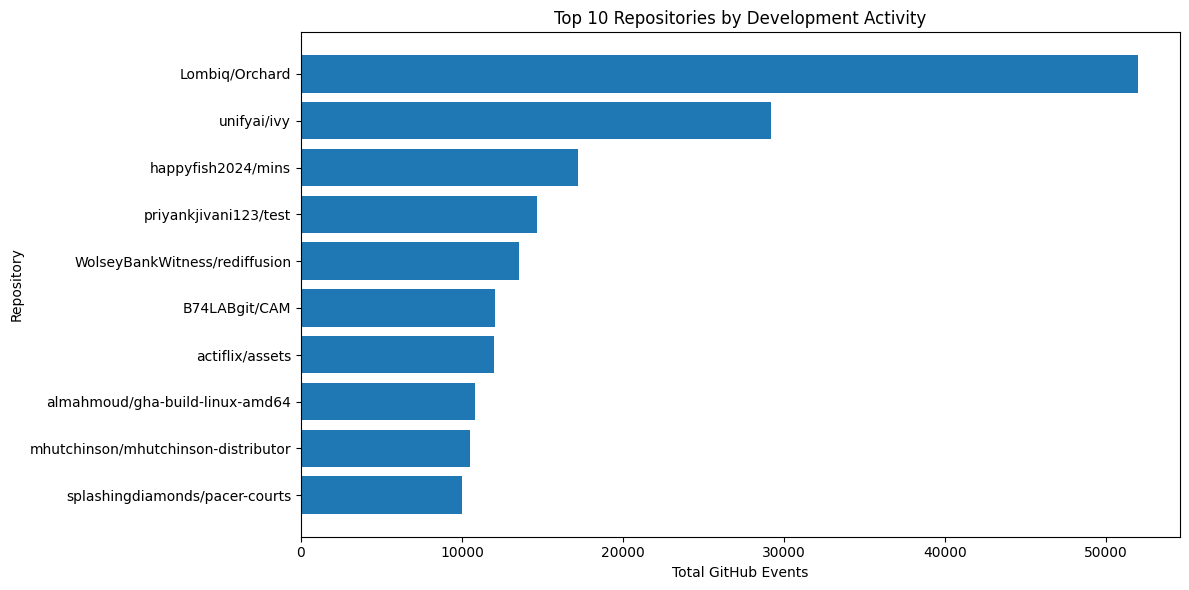

In [55]:
# ============================================
# CHART 1: TOP REPOSITORIES BY ACTIVITY
# ============================================

import matplotlib.pyplot as plt

top_activity = (
    repository_activity_result
    .orderBy(F.desc("total_events"))
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_activity["name"][::-1],
    top_activity["total_events"][::-1]
)

plt.xlabel("Total GitHub Events")
plt.ylabel("Repository")
plt.title("Top 10 Repositories by Development Activity")
plt.tight_layout()
plt.show()

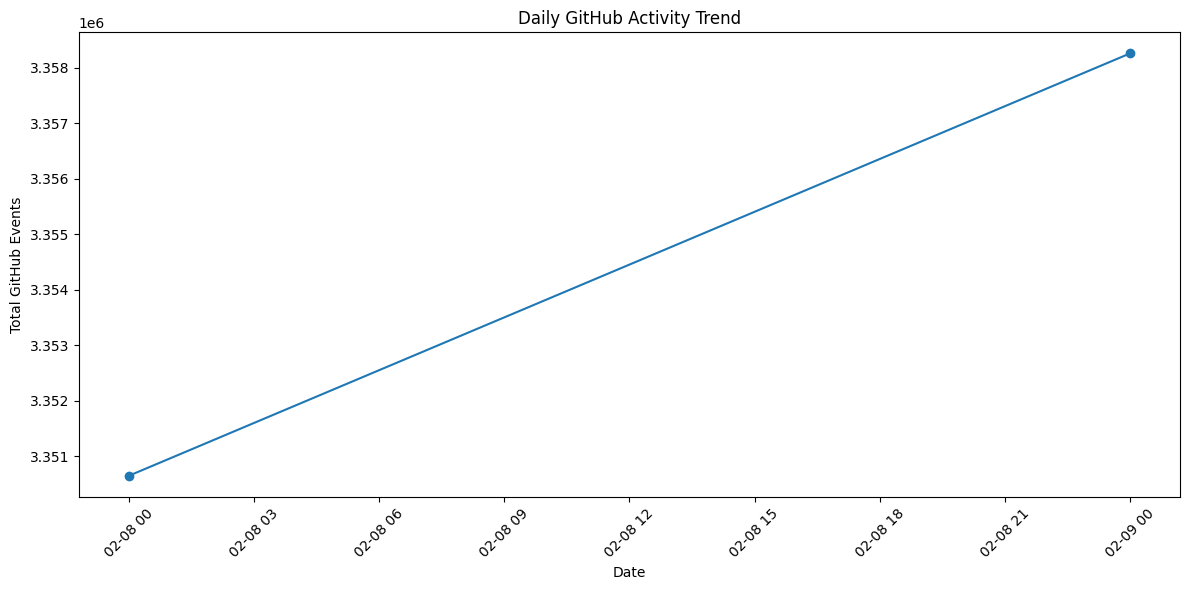

In [56]:
# ============================================
# CHART 2: DAILY GITHUB ACTIVITY TREND
# ============================================

daily_activity = (
    time_trend
    .orderBy("date")
    .toPandas()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_activity["date"],
    daily_activity["total_events"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Total GitHub Events")
plt.title("Daily GitHub Activity Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

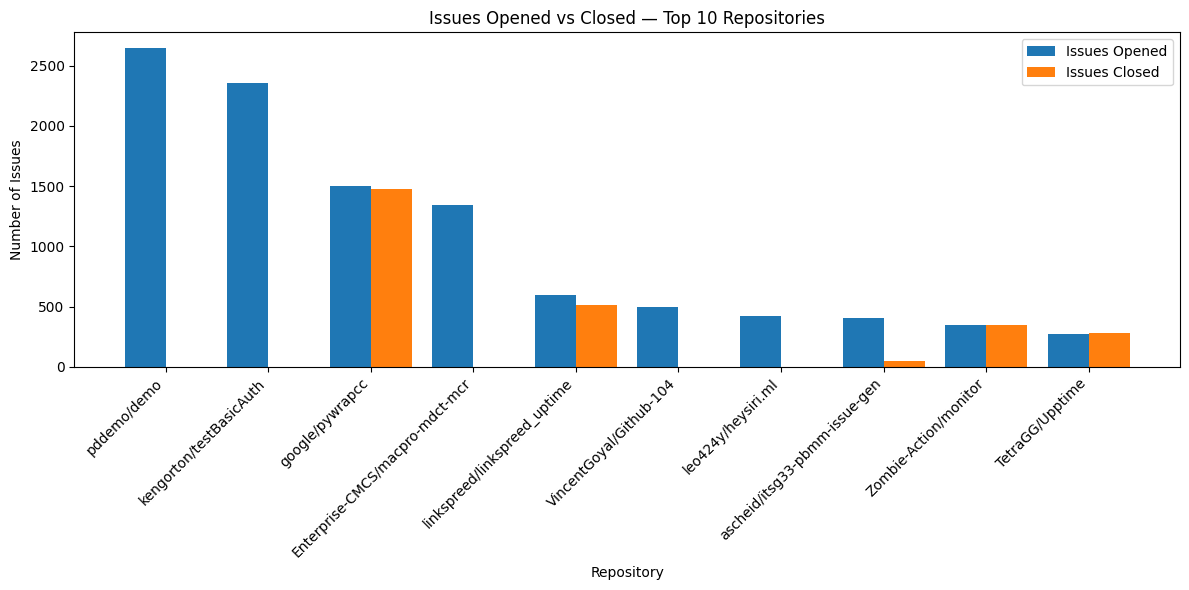

In [57]:
# ============================================
# CHART 3: ISSUES OPENED VS CLOSED
# ============================================

issue_chart = (
    issue_result
    .filter(
        (F.col("issues_opened") > 0) |
        (F.col("issues_closed") > 0)
    )
    .orderBy(F.desc("unique_issues"))
    .limit(10)
    .toPandas()
)

x = range(len(issue_chart))

plt.figure(figsize=(12, 6))

plt.bar(
    [i - 0.2 for i in x],
    issue_chart["issues_opened"],
    width=0.4,
    label="Issues Opened"
)

plt.bar(
    [i + 0.2 for i in x],
    issue_chart["issues_closed"],
    width=0.4,
    label="Issues Closed"
)

plt.xlabel("Repository")
plt.ylabel("Number of Issues")
plt.title("Issues Opened vs Closed — Top 10 Repositories")
plt.xticks(
    list(x),
    issue_chart["repository"],
    rotation=45,
    ha="right"
)
plt.legend()
plt.tight_layout()
plt.show()

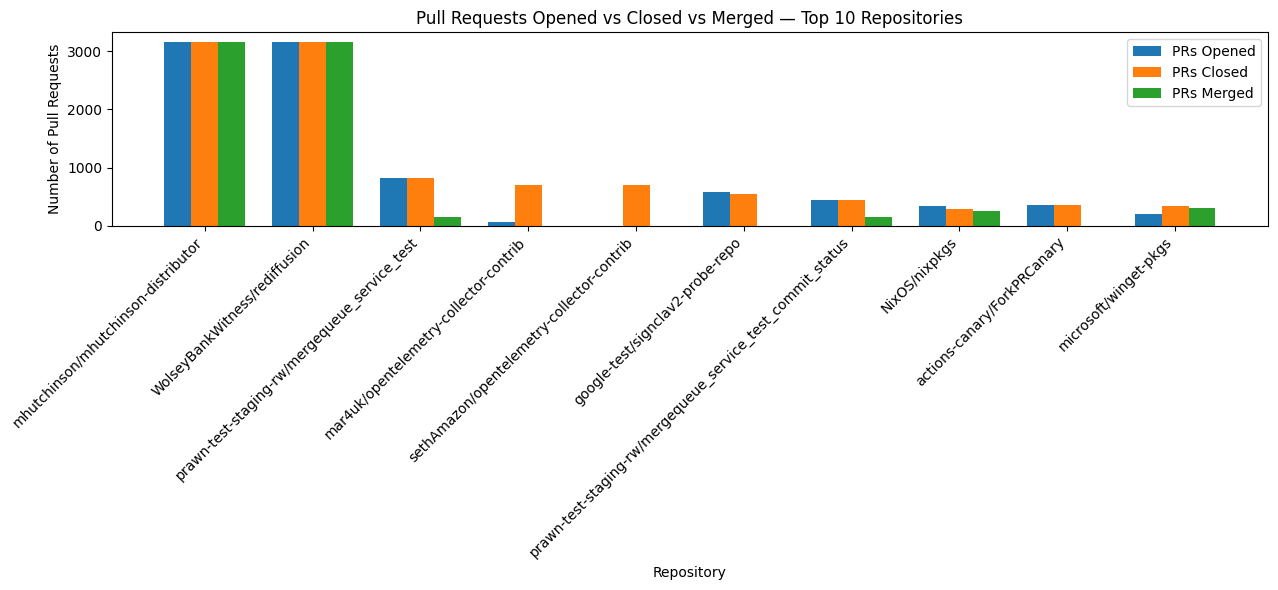

In [58]:
# ============================================
# CHART 4: PULL REQUESTS OPENED vs CLOSED vs MERGED
# ============================================

pr_chart = (
    pr_result
    .filter(F.col("unique_prs") > 0)
    .orderBy(F.desc("unique_prs"))
    .limit(10)
    .toPandas()
)

x = range(len(pr_chart))

plt.figure(figsize=(13, 6))

plt.bar(
    [i - 0.25 for i in x],
    pr_chart["prs_opened"],
    width=0.25,
    label="PRs Opened"
)

plt.bar(
    x,
    pr_chart["prs_closed"],
    width=0.25,
    label="PRs Closed"
)

plt.bar(
    [i + 0.25 for i in x],
    pr_chart["prs_merged"],
    width=0.25,
    label="PRs Merged"
)

plt.xlabel("Repository")
plt.ylabel("Number of Pull Requests")
plt.title("Pull Requests Opened vs Closed vs Merged — Top 10 Repositories")

plt.xticks(
    list(x),
    pr_chart["repository"],
    rotation=45,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

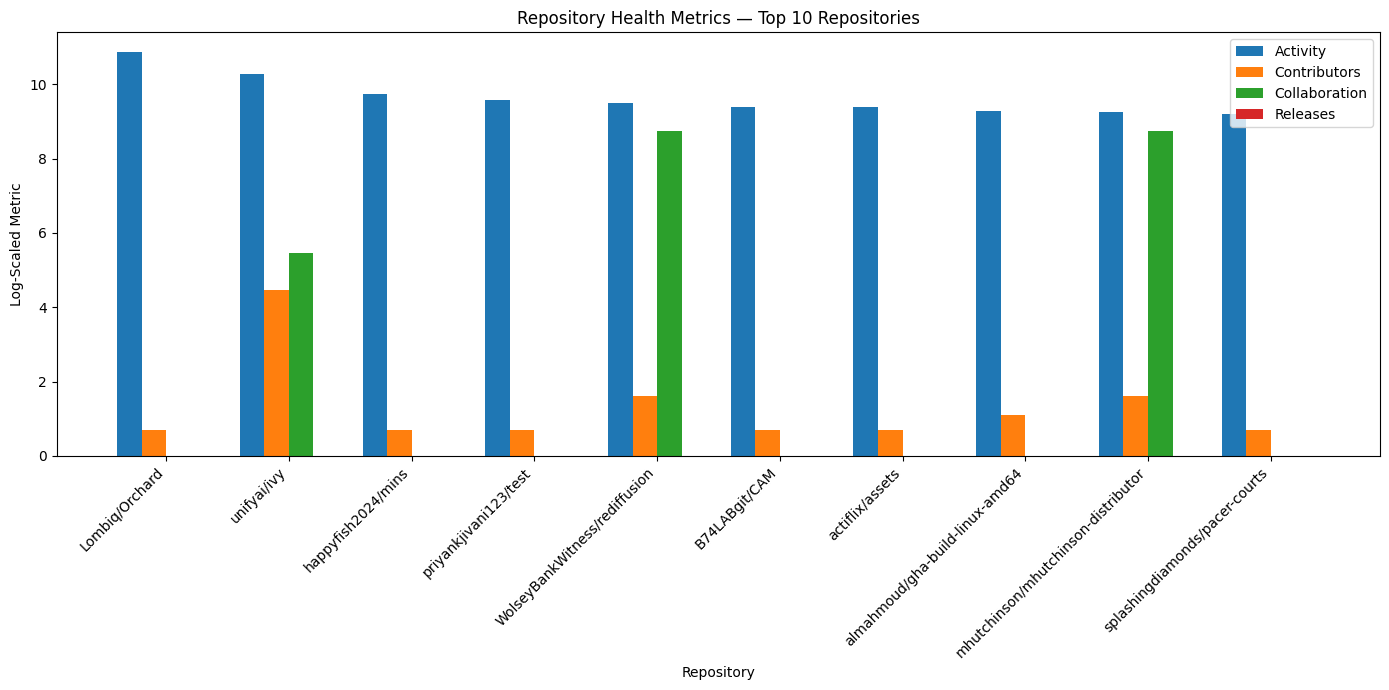

In [59]:
# ============================================
# CHART 5: REPOSITORY HEALTH METRICS
# ============================================

health_chart = (
    repository_health_metrics
    .orderBy(F.desc("activity_score"))
    .limit(10)
    .toPandas()
)

x = range(len(health_chart))

plt.figure(figsize=(14, 7))

plt.bar(
    [i - 0.3 for i in x],
    health_chart["activity_score"],
    width=0.2,
    label="Activity"
)

plt.bar(
    [i - 0.1 for i in x],
    health_chart["contributor_score"],
    width=0.2,
    label="Contributors"
)

plt.bar(
    [i + 0.1 for i in x],
    health_chart["collaboration_score"],
    width=0.2,
    label="Collaboration"
)

plt.bar(
    [i + 0.3 for i in x],
    health_chart["release_score"],
    width=0.2,
    label="Releases"
)

plt.xlabel("Repository")
plt.ylabel("Log-Scaled Metric")
plt.title("Repository Health Metrics — Top 10 Repositories")

plt.xticks(
    list(x),
    health_chart["name"],
    rotation=45,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

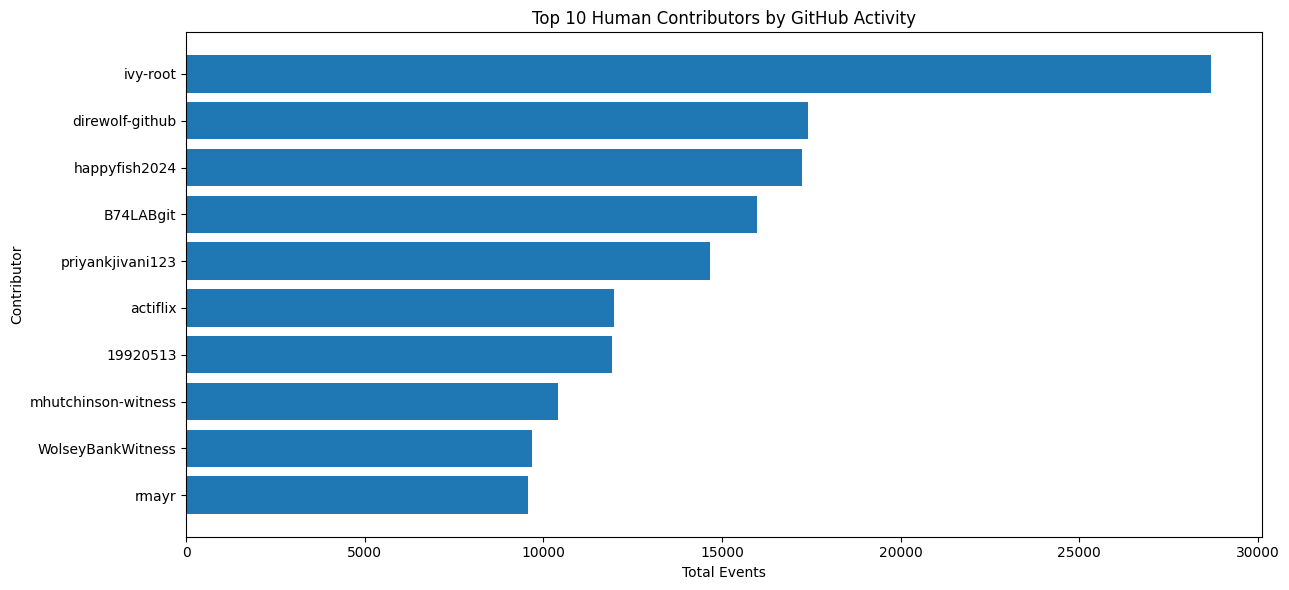

In [60]:
# ============================================
# CHART 6: TOP HUMAN CONTRIBUTORS
# ============================================

contributor_chart = (
    human_contributors
    .orderBy(F.desc("total_events"))
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(13, 6))

plt.barh(
    contributor_chart["contributor"][::-1],
    contributor_chart["total_events"][::-1]
)

plt.xlabel("Total Events")
plt.ylabel("Contributor")
plt.title("Top 10 Human Contributors by GitHub Activity")

plt.tight_layout()
plt.show()

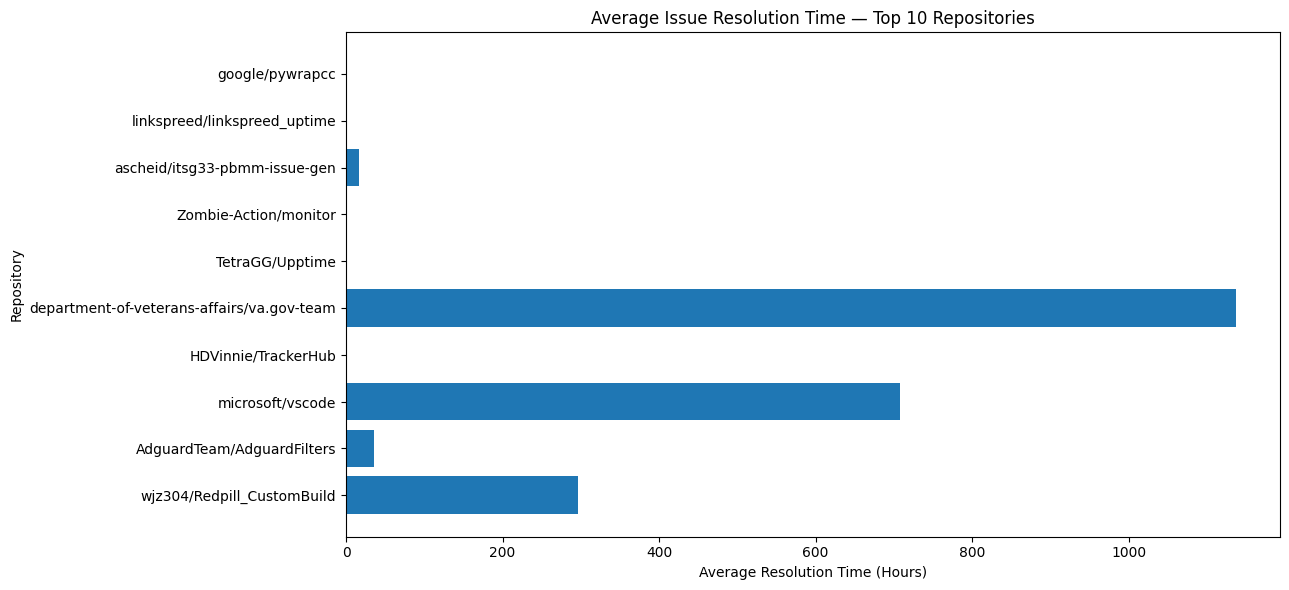

In [61]:
# ============================================
# CHART 7: ISSUE RESOLUTION TIME
# ============================================

issue_time_chart = (
    issue_result
    .filter(F.col("avg_resolution_hours").isNotNull())
    .filter(F.col("avg_resolution_hours") > 0)
    .orderBy(F.desc("unique_issues"))
    .limit(10)
    .toPandas()
)

plt.figure(figsize=(13, 6))

plt.barh(
    issue_time_chart["repository"][::-1],
    issue_time_chart["avg_resolution_hours"][::-1]
)

plt.xlabel("Average Resolution Time (Hours)")
plt.ylabel("Repository")
plt.title("Average Issue Resolution Time — Top 10 Repositories")

plt.tight_layout()
plt.show()

In [63]:
summary = final_master.agg(
    F.sum("total_events").alias("total_events"),
    F.sum("unique_contributors").alias("total_contributor_records"),
    F.sum("push_events").alias("push_events"),
    F.sum("issue_events").alias("issue_events"),
    F.sum("pull_request_events").alias("pull_request_events"),
    F.sum("release_events").alias("release_events"),
    F.sum("fork_events").alias("fork_events")
)

summary.show(truncate=False)

print("Total repositories:", final_master.select("repository").distinct().count())

print("\nDate range:")
time_trend.select(
    F.min("date").alias("start_date"),
    F.max("date").alias("end_date")
).show()

+------------+-------------------------+-----------+------------+-------------------+--------------+-----------+
|total_events|total_contributor_records|push_events|issue_events|pull_request_events|release_events|fork_events|
+------------+-------------------------+-----------+------------+-------------------+--------------+-----------+
|6708903     |1374855                  |4770207    |180880      |705114             |46249         |126433     |
+------------+-------------------------+-----------+------------+-------------------+--------------+-----------+

Total repositories: 1042029

Date range:
+----------+----------+
|start_date|  end_date|
+----------+----------+
|2023-02-08|2023-02-09|
+----------+----------+



In [64]:
# Save dashboard-supporting analytics before the runtime resets

RESULTS_DIR = "/content/drive/MyDrive/OSSense_Data/results"

# Human contributor analytics
human_contributors.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv(f"{RESULTS_DIR}/human_contributors")

# Daily activity trend
time_trend.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv(f"{RESULTS_DIR}/time_trend")

print("✅ Dashboard-supporting analytics saved!")
print("Saved:")
print(" - human_contributors")
print(" - time_trend")

✅ Dashboard-supporting analytics saved!
Saved:
 - human_contributors
 - time_trend


In [66]:
# ============================================
# OSSense — Load Saved Analytics for Dashboard
# ============================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

BASE_DIR = "/content/drive/MyDrive/OSSense_Data"
RESULTS_DIR = f"{BASE_DIR}/results"

# Start Spark only if it isn't already running
try:
    spark
    print("Using existing Spark session.")
except NameError:
    spark = (
        SparkSession.builder
        .appName("OSSense-Dashboard")
        .master("local[*]")
        .config("spark.driver.memory", "6g")
        .config("spark.sql.shuffle.partitions", "16")
        .getOrCreate()
    )

spark.sparkContext.setLogLevel("WARN")

# Load saved analytics
final_master = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(f"{RESULTS_DIR}/final_master")
)

repository_activity_result = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(f"{RESULTS_DIR}/repository_activity")
)

issue_result = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(f"{RESULTS_DIR}/issue_analytics")
)

pr_result = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(f"{RESULTS_DIR}/pr_analytics")
)

repository_health_metrics = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(f"{RESULTS_DIR}/repository_health")
)

human_contributors = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(f"{RESULTS_DIR}/human_contributors")
)

time_trend = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(f"{RESULTS_DIR}/time_trend")
)

print("\n" + "="*50)
print("✅ OSSENSE ANALYTICS RESTORED")
print("="*50)

print(f"FINAL MASTER        : {final_master.count():,}")
print(f"REPOSITORY ACTIVITY : {repository_activity_result.count():,}")
print(f"ISSUE ANALYTICS     : {issue_result.count():,}")
print(f"PR ANALYTICS        : {pr_result.count():,}")
print(f"REPOSITORY HEALTH   : {repository_health_metrics.count():,}")
print(f"HUMAN CONTRIBUTORS  : {human_contributors.count():,}")
print(f"TIME TREND          : {time_trend.count():,}")

print("\n📊 Dashboard data is ready.")

Using existing Spark session.

✅ OSSENSE ANALYTICS RESTORED
FINAL MASTER        : 1,042,029
REPOSITORY ACTIVITY : 1,042,029
ISSUE ANALYTICS     : 52,271
PR ANALYTICS        : 191,842
REPOSITORY HEALTH   : 1,042,029
HUMAN CONTRIBUTORS  : 791,301
TIME TREND          : 2

📊 Dashboard data is ready.


## 12. Dashboard Data Preparation

In [67]:
# ============================================
# OSSense — Prepare Dashboard Data
# ============================================

import pandas as pd

# Convert only the relatively small analytical result tables
repo_pd = repository_activity_result.toPandas()
issue_pd = issue_result.toPandas()
pr_pd = pr_result.toPandas()
health_pd = repository_health_metrics.toPandas()
contributors_pd = human_contributors.toPandas()
trend_pd = time_trend.toPandas()

print("✅ Dashboard data converted to Pandas")

print("\nShapes:")
print("Repository activity :", repo_pd.shape)
print("Issue analytics     :", issue_pd.shape)
print("PR analytics        :", pr_pd.shape)
print("Repository health   :", health_pd.shape)
print("Contributors        :", contributors_pd.shape)
print("Time trend          :", trend_pd.shape)

✅ Dashboard data converted to Pandas

Shapes:
Repository activity : (1042029, 8)
Issue analytics     : (52271, 6)
PR analytics        : (191842, 7)
Repository health   : (1042029, 12)
Contributors        : (791301, 8)
Time trend          : (2, 6)


## 13. Interactive Dashboard

In [69]:
# ============================================================
# OSSense — Continue Dashboard After Repository Column Fix
# ============================================================

# Fix repository column name for repository activity data
top_repos = (
    repo_pd
    .rename(columns={"name": "repository"})
    .sort_values("total_events", ascending=False)
    .head(10)
    .copy()
)

# Make sure other repository tables have the expected column
if "name" in health_pd.columns and "repository" not in health_pd.columns:
    health_pd = health_pd.rename(columns={"name": "repository"})

# ============================================================
# 2. TOP REPOSITORIES
# ============================================================

fig2 = px.bar(
    top_repos.sort_values("total_events"),
    x="total_events",
    y="repository",
    orientation="h",
    title="Top 10 Repositories by Development Activity",
    labels={
        "total_events": "Total Events",
        "repository": "Repository"
    }
)

fig2.update_layout(
    template="plotly_white",
    height=500
)

fig2.show()


# ============================================================
# 3. CONTRIBUTOR ACTIVITY
# ============================================================

top_contributors = (
    contributors_pd
    .sort_values("total_events", ascending=False)
    .head(10)
    .copy()
)

fig3 = px.bar(
    top_contributors.sort_values("total_events"),
    x="total_events",
    y="contributor",
    orientation="h",
    title="Top 10 Human Contributors by Activity",
    labels={
        "total_events": "Events",
        "contributor": "Contributor"
    }
)

fig3.update_layout(
    template="plotly_white",
    height=500
)

fig3.show()


# ============================================================
# 4. ISSUE ANALYTICS
# ============================================================

top_issues = (
    issue_pd
    .groupby("repository", as_index=False)
    .agg(
        issues_opened=("issues_opened", "sum"),
        issues_closed=("issues_closed", "sum")
    )
    .sort_values("issues_opened", ascending=False)
    .head(10)
)

issue_long = top_issues.melt(
    id_vars="repository",
    value_vars=["issues_opened", "issues_closed"],
    var_name="status",
    value_name="count"
)

fig4 = px.bar(
    issue_long,
    x="repository",
    y="count",
    color="status",
    barmode="group",
    title="Issues Opened vs Closed — Top Repositories",
    labels={
        "repository": "Repository",
        "count": "Issue Count",
        "status": "Status"
    }
)

fig4.update_layout(
    template="plotly_white",
    height=500,
    xaxis_tickangle=-45
)

fig4.show()


# ============================================================
# 5. PULL REQUEST ANALYTICS
# ============================================================

top_prs = (
    pr_pd
    .groupby("repository", as_index=False)
    .agg(
        prs_opened=("prs_opened", "sum"),
        prs_closed=("prs_closed", "sum"),
        prs_merged=("prs_merged", "sum")
    )
    .sort_values("prs_opened", ascending=False)
    .head(10)
)

pr_long = top_prs.melt(
    id_vars="repository",
    value_vars=[
        "prs_opened",
        "prs_closed",
        "prs_merged"
    ],
    var_name="status",
    value_name="count"
)

fig5 = px.bar(
    pr_long,
    x="repository",
    y="count",
    color="status",
    barmode="group",
    title="Pull Requests Opened vs Closed vs Merged",
    labels={
        "repository": "Repository",
        "count": "Pull Request Count",
        "status": "Status"
    }
)

fig5.update_layout(
    template="plotly_white",
    height=500,
    xaxis_tickangle=-45
)

fig5.show()


# ============================================================
# 6. REPOSITORY HEALTH INDICATORS
# ============================================================

health_top = (
    health_pd
    .sort_values("activity_score", ascending=False)
    .head(10)
    .copy()
)

health_long = health_top.melt(
    id_vars="repository",
    value_vars=[
        "activity_score",
        "contributor_score",
        "collaboration_score",
        "release_score"
    ],
    var_name="metric",
    value_name="score"
)

fig6 = px.bar(
    health_long,
    x="repository",
    y="score",
    color="metric",
    barmode="group",
    title="Repository Health Indicators — Top Active Repositories",
    labels={
        "repository": "Repository",
        "score": "Log-scaled Indicator"
    }
)

fig6.update_layout(
    template="plotly_white",
    height=550,
    xaxis_tickangle=-45
)

fig6.show()


print("\n" + "="*70)
print("✅ OSSENSE DASHBOARD COMPLETED")
print("="*70)
print("Dataset window : 8 Feb 2023 → 9 Feb 2023")
print("Events         :", f"{TOTAL_EVENTS:,}")
print("Repositories   :", f"{TOTAL_REPOS:,}")
print("Contributors   :", f"{TOTAL_CONTRIBUTORS:,}")
print("="*70)


✅ OSSENSE DASHBOARD COMPLETED
Dataset window : 8 Feb 2023 → 9 Feb 2023
Events         : 6,708,903
Repositories   : 1,042,029
Contributors   : 791,301
